# Проект. Исследование стартапов

## Цель и задачи  

**Цель проекта:**

- Провести исследование исторических данных о финансировании стартапов, выявить закономерности по объемам, типам и динамике инвестиций и на основе полученных выводов дать обоснованные рекомендации по инвестиционной стратегии с позиции инвестора по состоянию на начало 2015 года.

**Задачи проекта:**

1. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений, привести типы данных к корректным;
2. Выделить группы компаний по срокам финансирования и сравнить их по количеству и объему инвестиций;
3. Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе;
4. Определить типичные и аномальные значения объемов финансирования, исключить выбросы и ограничить период исследования;
5. Сравнить популярность и объемы разных типов финансирования;
6. Проанализировать динамику раундов и объемов инвестиций по годам, а также изменения в массовых сегментах рынка;
7. Рассчитать долю возврата средств для разных типов финансирования и оценить ее устойчивость;
8. Подвести итоговые выводы и дать рекомендации по инвестиционной стратегии с позиции инвестора по состоянию на начало 2015 года.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета - `cb_investments.zip`. Внутри архива один файл - `cb_investments.csv`.

**Описание данных:**
* `name` — название компании.

* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета - `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

**Описание данных:**
* `year` — год возврата средств.

* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

Начнем с загрузки библиотек и датасетов `cb_investments` и `cb_returns`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn. Данные датасетов сохраним в двух переменных: `investments_df` и `returns_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные investments_df и returns_df

investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
returns_df = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv').set_index('year')

Познакомимся с данными датасета `investments_df` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран

investments_df.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Xavier University,http://www.xavier.edu/,NaN,NaN,"1,90,00,000",operating,USA,OH,Cincinnati,Cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tulane University,http://tulane.edu/,|Education|,Education,"1,20,00,000",operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Duke University,http://www.duke.edu,|Education|,Education,"87,00,000",operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"Virginia Commonwealth University, Richmond",http://www.vcu.edu/,NaN,NaN,"60,00,000",operating,USA,VA,Richmond,Richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,WeGame,http://www.WeGame.com,|Social Media|,Social Media,"35,00,000",acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме

investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датасет `investments_df` содержит **54 294 строки** и **40 столбцов** с информацией о компаниях и привлеченном финансировании.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов **требуют дополнительной обработки**. Столбцы `market` и `funding_total_usd` имеют лишний пробел в начале названия, поэтому необходимо привести их к единому формату;
- Типы данных **определены некорректно** в ряде столбцов:
  - `funding_total_usd` имеет тип `object` вместо числового, предположительно из-за разделителей (например, `9,00,00,000`). Данные требуют очистки и преобразования;
  
  - `first_funding_at`, `mid_funding_at`, `last_funding_at`, `founded_at`, `founded_month`, `founded_quarter` хранятся как `object`, их необходимо привести к типу `datetime`;
  
  - `funding_rounds` имеет тип `float64`, хотя логически должен быть целочисленным;
- В данных **присутствуют пропуски**:
  - в столбце `name` - 4 857 значений;
  
  - в столбце `homepage_url` - 8 305 значений;
  - в столбцах `category_list` и `market` - по 8 817 значений;
  - в столбце `status` - 6 170 значений;
  - в столбцах `country_code` и `region` - 10 129 значений;
  - в столбце `state_code` - 24 133 значения;
  - в столбце `city` - 10 972 значения;
  - в столбце `participants` - 23 821 значение;
  - в столбцах `founded_at`, `founded_year` - 15 740 значений;
  - в столбце `mid_funding_at` - 19 006 значений;
- Числовые столбцы финансирования (`seed`, `venture`, `angel` и др.) имеют тип `float64` и пропусков не содержат, имеют **49 438 непустых значений** в каждом;
- На данном этапе значения столбцов **визуально соответствуют их описанию**, однако строка 1 (`University of New Brunswick`) содержит `NaN` в полях `category_list`, `market`, `country_code`, `state_code`, `region`, `city`, что указывает на неполноту данных по ряду компаний.

Далее необходимо изучить второй датасет `returns_df`:

In [5]:
# Выводим первые строки датафрейма на экран

returns_df.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим информацию о датафрейме

returns_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


Датасет `returns_df` содержит **15 строк** и **14 столбцов** с информацией о суммах возвратов по типам финансирования в миллионах долларов по годам.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов **соответствуют описанию** и оформлены в едином стиле, дополнительная обработка не требуется;
- Типы данных **определены корректно**:
  - `year` имеет тип `int64`, что соответствует целочисленному году;
  - все остальные 13 столбцов имеют тип `float64`, что корректно для денежных сумм с дробной частью;
- **Пропуски отсутствуют**, все 14 столбцов содержат по 15 непустых значений;
- На данном этапе значения столбцов **визуально соответствуют их описанию**, суммы возвратов выражены в миллионах долларов и имеют ненулевые значения для наиболее распространенных типов финансирования (`venture`, `seed`, `undisclosed`);
- Столбцы `equity_crowdfunding`, `grant` и `product_crowdfunding` содержат нулевые значения на протяжении всего наблюдаемого периода. Вероятно, эти инструменты финансирования не применялись или не генерировали возвратов в рассматриваемые годы.

### 1.2. Предобработка данных

Проверим названия столбцов и приведем их к единому стилю, чтобы упростить работу с данными и снизить вероятность ошибок при обращении к признакам.

In [7]:
# Почистим названия столбцов, уберем лишние пробелы и приведем к нижнему регистру

investments_df.columns = investments_df.columns.str.strip()
investments_df.columns = investments_df.columns.str.lower()
investments_df['market'] = investments_df['market'].str.strip()
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

- Названия столбцов были очищены от лишних пробелов ( столбцы `market`,`funding_total_usd `) и приведены к нижнему регистру (столбцы `round_a` - `round_h`); 
- Это позволило стандартизировать структуру датасета и упростить обращение к признакам;
- Все столбцы теперь имеют единый и удобный для работы стиль.

---

Очистим столбец `funding_total_usd` и приведем его к числовому типу, чтобы обеспечить корректность расчетов и возможность анализа финансовых показателей.

In [8]:
# Найдем значения в funding_total_usd, которые не получится перевести в число
mask = pd.to_numeric(
    investments_df['funding_total_usd']
    .astype(str)
    .str.replace(',', '', regex=False),
    errors='coerce'
).isna()

# Посмотрим что за значения сломали конвертацию
investments_df.loc[mask, 'funding_total_usd'].unique()

array([' -   ', nan], dtype=object)

In [9]:
# Очистим funding_total_usd, убирем все нечисловые символы и переведем в целое число

investments_df['funding_total_usd'] = pd.to_numeric(
    investments_df['funding_total_usd']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
).astype('Int64')

В столбце `funding_total_usd` были выявлены нечисловые значения (например, '-' и пропуски), из-за которых 8532 записей не могли быть корректно преобразованы в числовой тип. После удаления лишних символов столбец был приведен к типу Int64. Это позволило использовать его для дальнейшего анализа финансовых показателей.

---

Приведем столбцы с датами и временем к формату datetime, чтобы корректно работать с временными интервалами и анализировать динамику данных.

In [10]:
# Переведем столбцы с датами в формат datetime

columns_date = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]
for col in columns_date:
    investments_df[col] = pd.to_datetime(investments_df[col], errors='coerce')

In [11]:
# Переведем founded_month в datetime

investments_df['founded_month'] = pd.to_datetime(
    investments_df['founded_month'],
    errors='coerce'
)

In [12]:
# Переведем founded_quarter в формат квартала

investments_df['founded_quarter'] = pd.PeriodIndex(
    investments_df['founded_quarter'],
    freq='Q'
)

In [13]:
# Приведем founded_year к целочисленному типу

investments_df['founded_year'] = investments_df['founded_year'].astype('Int64')

In [14]:
# Понизим разрядность числовых столбцов для экономии памяти
int_cols = ['funding_rounds', 'participants', 'founded_year']
float_cols = ['funding_total_usd', 'seed', 'venture', 'equity_crowdfunding',
              'undisclosed', 'convertible_note', 'debt_financing', 'angel',
              'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
              'secondary_market', 'product_crowdfunding',
              'round_a', 'round_b', 'round_c', 'round_d',
              'round_e', 'round_f', 'round_g', 'round_h']

for col in int_cols:
    if col in investments_df.columns:
        investments_df[col] = pd.to_numeric(investments_df[col], errors='coerce').astype('Int32')

for col in float_cols:
    if col in investments_df.columns:
        investments_df[col] = pd.to_numeric(investments_df[col], errors='coerce').astype('float32')

- Столбцы с датами `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` были приведены к формату datetime. Некорректные значения автоматически преобразованы в NaT. Это позволяет корректно рассчитывать временные интервалы и анализировать динамику;
- Целочисленные столбцы `funding_rounds`, `participants` и `founded_year` переведены в Int32 вместо Int64;

- Столбцы с суммами финансирования переведены в `float32` вместо `float64`;
- На текущем датасете экономия памяти небольшая, но в реальной практике при работе с большими объемами данных это снижает потребление памяти примерно вдвое.

---

Приведем текстовые признаки к единому виду и заполним пропуски, чтобы избежать дублирования категорий и сохранить данные для анализа

In [15]:
# Приведем текстовые столбцы к нижнему регистру и заполним пропуски заглушкой

object_columns = [
    'name',
    'homepage_url',
    'category_list',
    'market',
    'status',
    'country_code',
    'state_code',
    'region',
    'city'
]

for col in object_columns:
    investments_df[col] = investments_df[col].str.lower()
investments_df[object_columns] = investments_df[object_columns].fillna('unknown')

Текстовые столбцы были приведены к нижнему регистру, что устраняет дублирование значений из-за различий в написании. Пропуски заменены на 'unknown', что позволяет сохранить строки и использовать их в анализе без потери данных.

---

Удалим дубликаты и строки без данных о финансировании, чтобы исключить искажения и оставить только релевантные наблюдения.

In [16]:
# Создадим рабочую копию датасета, чтобы не изменять исходные данные

df = investments_df.copy()

In [17]:
# Посмотрим количество строк и столбцов в датасете до очистки

df.shape

(54294, 40)

In [18]:
# Посчитаем количество полных дубликатов 

df.duplicated().sum()

4855

In [19]:
# Удалим полные дубликаты и оставим только уникальные строки

df = df.drop_duplicates()

In [20]:
# Зафиксируем количество строк "до" очистки и "после" удаления дублей
rows_before = len(investments_df)
rows_after_duplicates = len(df)

# Посчитаем сколько строк было удалено как дубликаты
removed_duplicates = rows_before - rows_after_duplicates
display(removed_duplicates)

4855

In [21]:
# Проверим количество пропусков в столбце funding_total_usd до удаления

df['funding_total_usd'].isna().sum()

8532

In [22]:
# Удалим строки без данных о сумме финансирования

df = df[df['funding_total_usd'].notna()]

In [23]:
# Проверим, не осталось ли полностью пустых строк

df.isna().all(axis=1).sum()

0

In [24]:
# Удалим полностью пустые строки, так как они не несут информации

df = df[~df.isna().all(axis=1)]

In [25]:
# Проверим, не осталось ли дублей, пропусков в funding и пустых строк

print('Дубликаты:', df.duplicated().sum())
print('Пропуски в funding_total_usd:', df['funding_total_usd'].isna().sum())
print('Полностью пустые строки:', df.isna().all(axis=1).sum())

Дубликаты: 0
Пропуски в funding_total_usd: 0
Полностью пустые строки: 0


In [26]:
# Посчитаем итоговое количество строк после всех этапов очистки
final_rows = len(df)

# Посчитаем общее количество удаленных строк
total_removed = rows_before - final_rows

# Посчитаем долю удаленных строк в процентах
total_removed_share = round(total_removed / rows_before * 100, 2)


# Выведем итоговую сводку по очистке данных
print('Строк было до очистки:', rows_before)
print('Строк осталось после очистки:', final_rows)
print('Удалено строк:', total_removed)
print('Доля удалённых строк (%):', total_removed_share)

Строк было до очистки: 54294
Строк осталось после очистки: 40907
Удалено строк: 13387
Доля удалённых строк (%): 24.66


- В данных обнаружено 4855 полных дубликатов что составляет 8.94% от исходного объема данных, которые были удалены;
- Также выявлено 8532 строки без информации о финансировании (15.7%), которые были исключены из анализа;
- В сумме удалено 13387 строк, что составляет 24.66% от исходного объема данных;
- После очистки в датасете не осталось дубликатов и пропусков в столбце `funding_total_usd`.

---

Заполним пропуски в `mid_funding_at` на основе временного интервала, чтобы восстановить недостающие значения и сохранить полноту данных.

In [27]:
# Рассчитаем середину интервала между первой и последней датой финансирования
df['mid_date'] = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2

# Заполним пропуски в mid_funding_at рассчитанными значениями
df['mid_funding_at'] = df['mid_funding_at'].fillna(df['mid_date'])

Пропуски в столбце `mid_funding_at` были заполнены значениями, рассчитанными как середина интервала между `first_funding_at` и `last_funding_at`. Это позволило восстановить недостающие значения на основе имеющихся данных.

---

Оценим размер оставшихся пропусков, чтобы понять качество данных и возможное влияние на результаты анализа.

In [28]:
# Оценим размер оставшихся пропусков в столбце

df['mid_funding_at'].isna().sum()

1

In [29]:
# Посмотри детальнее на данный пропуск

df.loc[df['mid_funding_at'].isna(), [
    'first_funding_at',
    'last_funding_at',
    'mid_funding_at',
    'name'
]]

,first_funding_at,last_funding_at,mid_funding_at,name
33041,NaT,2014-09-25,NaT,nubank


После заполнения остался 1 пропуск в столбце `mid_funding_at`. В данной строке отсутствует значение `first_funding_at`, при этом `last_funding_at` заполнен. Из-за отсутствия начальной даты невозможно корректно вычислить середину интервала, поэтому значение не было восстановлено. Это единичный случай и он не оказывает влияния на общий анализ.

---

### Промежуточный вывод по предобработке данных

- После предобработки было удалено 13 387 строк, что составляет 24.66% от исходного объема данных;
- Основной частью удаленных записей являются дубликаты и строки без информации о финансировании;
- После очистки в датасете не осталось пропусков в ключевом столбце `funding_total_usd`, что делает данные пригодными для анализа;
- Несмотря на удаление примерно четверти данных, оставшийся объем можно считать достаточным для решения задач проекта, так как сохранены все необходимые признаки и устранены критические пропуски.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Создадим новый признак для длительности финансирования в днях, и на его основе разобьем все компании на три группы в зависимости от того, как долго они привлекали инвестиции.

In [30]:
# Посчитаем разницу между первой и последней датой финансирования в днях

df['funding_duration'] = (df['last_funding_at'] - df['first_funding_at']).dt.days

In [31]:
# Проверим пропуски в funding_duration

print(df['funding_duration'].isna().sum())

2


- В столбце `funding_duration` обнаружено 2 пропуска; 
- Они связаны с отсутствием дат финансирования и отнесены к категории заглушке, которая исключена из дальнейшего анализа.

In [32]:
# Проведем категоризацию и разделим все компании на три группы:

def categorize(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_rounds'] > 1 and row['funding_duration'] <= 365:
        return 'Срок финансирования до года'
    elif row['funding_rounds'] > 1 and row['funding_duration'] > 365:
        return 'Срок финансирования более года'
    else:
        return 'Не определено'
    
df['funding_group'] = df.apply(categorize, axis=1)

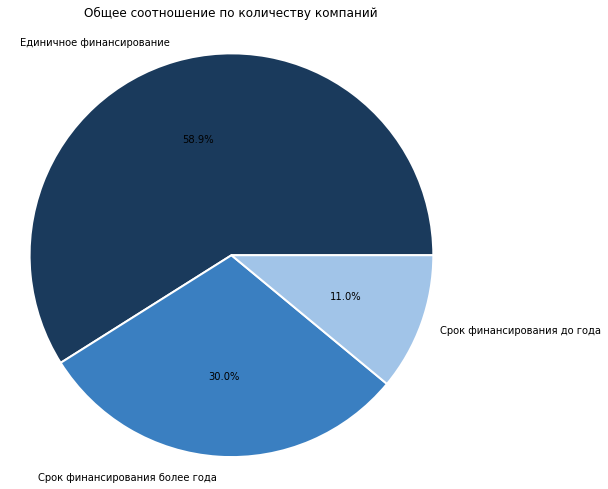

In [33]:
# Посчитаем количество компаний в каждой категории финансирования
total_counts = df['funding_group'].value_counts()
total_counts = total_counts[total_counts.index != 'Не определено']

# Зададим единую цветовую палитру для категорий
colors = ['#1A3A5C', '#3A7FC1', '#A1C4E8']

# Зададим размер для круговой диаграммы
plt.figure(figsize=(8, 8))

# Построим pie chart
plt.pie(
    total_counts.values,
    labels=total_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Добавим заголовок графика
plt.title('Общее соотношение по количеству компаний\n')

# Сделаем диаграмму круглой (без искажений)
plt.axis('equal')

plt.show()

- Наибольшая доля компаний относится к категории "Единичное финансирование" и составляет 24 113 компаний (59%). Это указывает на то, что большинство компаний привлекали инвестиции только один раз;
- Компании со сроком финансирования более года составляют 12 291 (30%). Это отражает значительную долю проектов, развивающихся через несколько раундов финансирования в течение длительного периода;
- Наименьшая доля приходится на компании со сроком финансирования до года и составляет 4 501 (11%), что говорит о сравнительно редком случае быстрого привлечения инвестиций;

Данное распределение показывает, что рынок характеризуется преобладанием компаний с единичным раундом финансирования, тогда как многоэтапное и особенно быстрое финансирование встречается существенно реже.

---

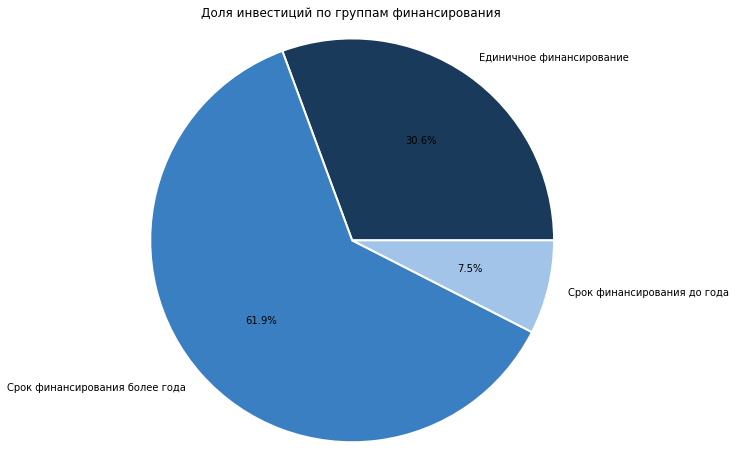

In [34]:
# Посчитаем общий объем инвестиций для каждой группы
investment_sum = df[df['funding_group'] != 'Не определено'].groupby('funding_group')['funding_total_usd'].sum()

# Зададим единую цветовую палитру для категорий
colors = ['#1A3A5C', '#3A7FC1', '#A1C4E8']

# Зададим размер для круговой диаграммы
plt.figure(figsize=(8, 8))

# Построим pie chart
plt.pie(
    investment_sum.values,
    labels=investment_sum.index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Добавим заголовок графика
plt.title('Доля инвестиций по группам финансирования')

# Сделаем диаграмму круглой (без искажений)
plt.axis('equal')

plt.show()

- Наибольшая доля инвестиций приходится на компании со сроком финансирования **более года** и составляет около 61.9%. Это указывает на то, что именно такие компании привлекают основную часть капитала и проходят через несколько раундов финансирования;

- Компании с **единичным финансированием** аккумулируют около 30.6% от общего объема инвестиций. Несмотря на то, что таких компаний больше всего по количеству, их вклад в общий объем инвестиций значительно ниже;

- Наименьшая доля инвестиций приходится на компании со сроком финансирования **до года** - около 7.5%, что говорит о том, что быстрые инвестиционные циклы сопровождаются относительно небольшими объемами привлеченных средств;

Данное распределение показывает, что основная масса инвестиций сосредоточена в компаниях с длительным циклом финансирования, тогда как компании с единичным или быстрым финансированием играют менее значимую роль с точки зрения объема привлеченных средств.

### 2.2 Выделение средних и нишевых сегментов рынка

Посмотрим на столбец `market` и разберемся, какие сегменты рынка представлены в данных. Сгруппируем их по размеру (массовые, средние, нишевые) и заменим мелкие сегменты на заглушки, чтобы упростить дальнейший анализ.

In [35]:
# Посчитаем количество компаний в каждом сегменте рынка

df['market_count'] = df.groupby('market')['market'].transform('count')

In [36]:
# Создадим функцию для классификации сегментов по размеру

def segment(x):
    if x > 120:
        return 'Массовый сегмент'
    elif 35 <= x <= 120:
        return 'Средний сегмент'
    else:
        return 'Нишевый сегмент'

df['market_type'] = df['market_count'].apply(segment)

Нишевых сегментов: 16
Средних сегментов: 38
Массовых сегментов: 46


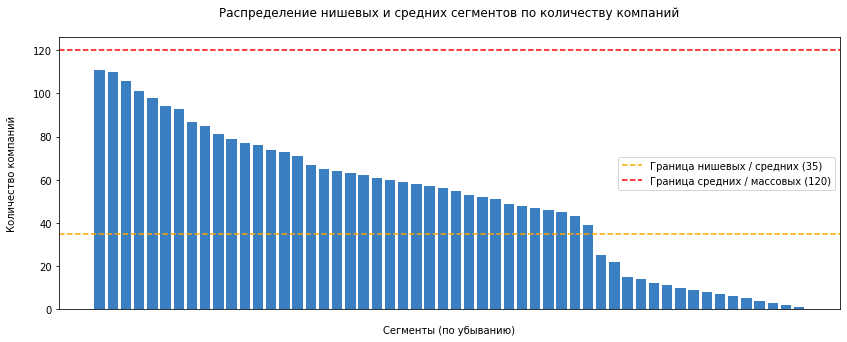

In [37]:
# Возьмем уникальные счетчики компаний по сегментам из сохраненного столбца
market_counts = df['market_count'].drop_duplicates().sort_values(ascending=False)

# Выведем количество сегментов в каждой категории
print(f"Нишевых сегментов: {(market_counts < 35).sum()}")
print(f"Средних сегментов: {((market_counts >= 35) & (market_counts <= 120)).sum()}")
print(f"Массовых сегментов: {(market_counts > 120).sum()}")

# Отфильтруем только нишевые и средние сегменты для читаемости графика
market_counts_filtered = market_counts[market_counts <= 120]

# Построим график распределения сегментов с границами категорий
plt.figure(figsize=(14, 5))
plt.bar(range(len(market_counts_filtered)), market_counts_filtered.values, color='#3A7FC1')
plt.axhline(y=35, color='orange', linestyle='--', linewidth=1.5, label='Граница нишевых / средних (35)')
plt.axhline(y=120, color='red', linestyle='--', linewidth=1.5, label='Граница средних / массовых (120)')
plt.title('Распределение нишевых и средних сегментов по количеству компаний\n')
plt.xlabel('\nСегменты (по убыванию)')
plt.ylabel('Количество компаний\n')
plt.xticks([])
plt.legend()

plt.show()

In [38]:
# Заменим значения в столбце market

df.loc[df['market_type'] == 'Средний сегмент', 'market'] = 'mid'
df.loc[df['market_type'] == 'Нишевый сегмент', 'market'] = 'niche'

- В датасете выявлено 100 уникальных сегментов рынка: 46 массовых (более 120 компаний), 38 средних (35-120 компаний) и 16 нишевых (менее 35 компаний);
- Несмотря на то что массовых сегментов больше по количеству, нишевые и средние сегменты в сумме составляют 54% от общего числа, что говорит о значительной фрагментации рынка;
- Для упрощения дальнейшего анализа нишевые и средние сегменты объединены в заглушки `niche` и `mid`, индивидуальные сегменты внутри этих групп не рассматриваются.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Посмотрим на распределение объемов финансирования и найдем компании с аномально высокими или низкими суммами. Для этого используем метод IQR, который помогает определить границы нормального диапазона значений отдельно для каждого сегмента рынка.

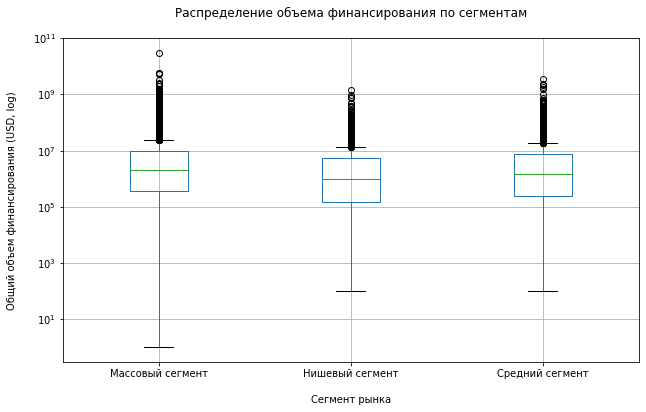

In [39]:
# Построим boxplot распределения финансирования по сегментам
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='funding_total_usd', by='market_type', ax=ax)

ax.set_yscale('log')
plt.suptitle('')
plt.title('Распределение объема финансирования по сегментам\n')
ax.set_xlabel('\nСегмент рынка')
ax.set_ylabel('Общий объем финансирования (USD, log)\n')

plt.show()

In [40]:
# Посмотрим на описательные статистики финансирования по сегментам

df.groupby('market_type')['funding_total_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
market_type,,,,,,,,
Массовый сегмент,36236.0,15855686.0,175929216.0,1.0,375000.0,2000000.0,10000000.0,3.007950e+10
Нишевый сегмент,830.0,17674318.0,85200424.0,100.0,150000.0,972500.0,5387727.5,1.498515e+09
Средний сегмент,3841.0,16068048.0,97289000.0,100.0,250000.0,1500000.0,7850000.0,3.500000e+09


Описательные статистики подтверждают картину с boxplot. 

- Медиана финансирования в массовом сегменте (1 400 000 USD) выше, чем в среднем (992 841 USD) и нишевом (555 000 USD); 
- IQR массового сегмента составляет от 265 000 до 5 190 096 USD, что шире, чем у нишевого (100 000 - 2 500 000 USD) и среднего (199 729 - 3 500 000 USD);
- Среднее во всех трех сегментах значительно превышает медиану из-за крупных выбросов сверху, что подтверждает необходимость применения метода IQR для их выявления.

In [41]:
# Выведем интервал типичных значений по каждому сегменту

for segment, group in df.groupby('market_type')['funding_total_usd']:
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    print(f"{segment}: типичный интервал [{q1:,.0f} - {q3:,.0f}] USD")

Массовый сегмент: типичный интервал [375,000 - 10,000,000] USD
Нишевый сегмент: типичный интервал [150,000 - 5,387,728] USD
Средний сегмент: типичный интервал [250,000 - 7,850,000] USD


- Типичный диапазон финансирования для массового сегмента составляет от 375 000 до 10 000 000 USD;
- Для нишевого сегмента типичный диапазон ниже, от 150 000 до 5 387 728 USD, что отражает меньшие объемы привлеченных средств в узкоспециализированных направлениях;
- Средний сегмент занимает промежуточное положение от 250 000 до 7 850 000 USD;
- Все три сегмента имеют значительное количество выбросов в верхней части распределения, компании с аномально высоким финансированием присутствуют в каждом сегменте;
- Медиана финансирования во всех сегментах сосредоточена в диапазоне 10⁶ USD, что соответствует типичному раунду финансирования в 1-5 млн USD.

In [42]:
# Посчитаем квартили и IQR по каждому типу сегмента
Q1 = df.groupby('market_type')['funding_total_usd'].quantile(0.25)
Q3 = df.groupby('market_type')['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

bounds = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'lower_bound': Q1 - 1.5 * IQR,
    'upper_bound': Q3 + 1.5 * IQR
})

# Напишем фуункцию для определения выброса
def is_outlier(row):
    lb = bounds.loc[row['market_type'], 'lower_bound']
    ub = bounds.loc[row['market_type'], 'upper_bound']
    return (row['funding_total_usd'] < lb) or (row['funding_total_usd'] > ub)

# Создадим столбец с флагом выброса
df['is_outlier'] = df.apply(is_outlier, axis=1)

# Отобразим долю выбросов по конкретным сегментам рынка
outlier_share = df.groupby('market')['is_outlier'].mean().sort_values(ascending=False)
print(outlier_share.head(10))

market
semiconductors         0.322314
clean technology       0.276271
health care            0.270042
web hosting            0.261792
technology             0.247899
biotechnology          0.230641
security               0.171076
cloud computing        0.164474
enterprise software    0.160753
niche                  0.159036
Name: is_outlier, dtype: float64


- Наибольшая доля компаний с аномальным финансированием наблюдается в сегменте `semiconductors`, где 32% компаний получили финансирование за пределами типичного диапазона;

- На 2-м и 3-м местах `clean technology` c 28% и `health care` c 27%;
- Высокая доля выбросов также в `web hosting` (26%) и `technology` (25%);
- В топ-10 присутствуют `biotechnology` (23%), `security` (17%), `cloud computing` (16%),
  `enterprise software` (16%) и `niche` (16%).

- Стоит отметить, что высокая доля выбросов в ряде сегментов может быть связана не с ошибками в данных, а с особенностью распределения финансирования;
- Распределение сумм финансирования сильно скошено вправо, большинство компаний получают небольшие суммы, но редкие крупные сделки сильно растягивают правый хвост. В таких условиях стандартный метод IQR с множителем 1.5 дает слишком узкие границы и помечает как выбросы компании, которые на самом деле просто крупнее среднего;
- Для распределений с сильным правым скосом можно использовать более широкий множитель, например 3.0 вместо 1.5. Это позволило бы оставить в выборке больше реальных компаний и снизить долю ложных выбросов.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим, полные ли данные у нас за 2014 год, удалим компании с аномальным финансированием и оставим только те годы, в которых было достаточно активности на рынке (50 и более раундов финансирования).

In [43]:
# Проверим полноту данных за 2014 год
rounds_by_year = df[df['mid_funding_at'].dt.year == 2014]['funding_rounds'].sum()
print(f"Раундов финансирования в 2014 году: {rounds_by_year}")

# Сравним количество раундов по годам
df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum().tail(5)

Раундов финансирования в 2014 году: 7757


mid_funding_at
2010.0     8266
2011.0     9248
2012.0    11354
2013.0    14276
2014.0     7757
Name: funding_rounds, dtype: Int64

In [44]:
# Проверим наличие данных по каждому месяцу 2014 года

df[df['mid_funding_at'].dt.year == 2014].groupby(
    df['mid_funding_at'].dt.month
)['funding_rounds'].sum()

mid_funding_at
1.0     893
2.0     715
3.0     810
4.0     807
5.0     761
6.0     900
7.0     779
8.0     636
9.0     595
10.0    524
11.0    314
12.0     23
Name: funding_rounds, dtype: Int64

- Данные за 2014 год есть по всем 12 месяцам, но распределение неравномерное; 
- С января по июнь количество раундов держится на уровне 670-850 в месяц; 
- Начиная с июля заметно снижение, август - 579, сентябрь - 551, октябрь - 491; 
- В ноябре резкое падение до 287, а в декабре всего 21 раунд. Это подтверждает, что данные за 2014 год неполные. Второе полугодие, особенно ноябрь и декабрь, охвачено значительно хуже. Поэтому выводы по 2014 году стоит воспринимать как предварительные.

In [45]:
# Исключим компании с аномальным финансированием

df = df[df['is_outlier'] == False]
print(f"Строк после удаления выбросов: {len(df)}")

Строк после удаления выбросов: 35539


In [46]:
# Посчитаем количество раундов по годам на основе mid_funding_at
rounds_per_year = df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()

# Оставим только годы с 50 и более раундами
active_years = rounds_per_year[rounds_per_year >= 50].index
print(f"Годы с 50+ раундами: {list(active_years)}")

Годы с 50+ раундами: [1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]


In [47]:
# Оставим только компании, получавшие финансирование в активные годы

df = df[df['mid_funding_at'].dt.year.isin(active_years)]
print(f"Строк после фильтрации по активным годам: {len(df)}")

Строк после фильтрации по активным годам: 35492


- В 2014 году зафиксировано 7 757 раундов финансирования (значительно меньше чем в 2013 году - 14 276). Это указывает на то, что данные за 2014 год неполные и скорее всего датасет сформирован в середине года или часть раундов еще не была внесена в базу. Считать данные за 2014 год полными нельзя;
- После удаления компаний с аномальным финансированием датасет сократился до 35 539 строк;
- Активными годами (50+ раундов) признаны 1999-2014, после фильтрации осталось 35 492 строки, то есть отброшено лишь 47 записей с финансированием вне этого периода.

### 3.3. Анализ типов финансирования по объему и популярности

Сравним типы финансирования по двум параметрам:
1. Сколько денег они привлекли в сумме;
2. Как часто компании их использовали.

Это поможет понять, какие инструменты популярны, но дают небольшие суммы, а какие редкие, но крупные.


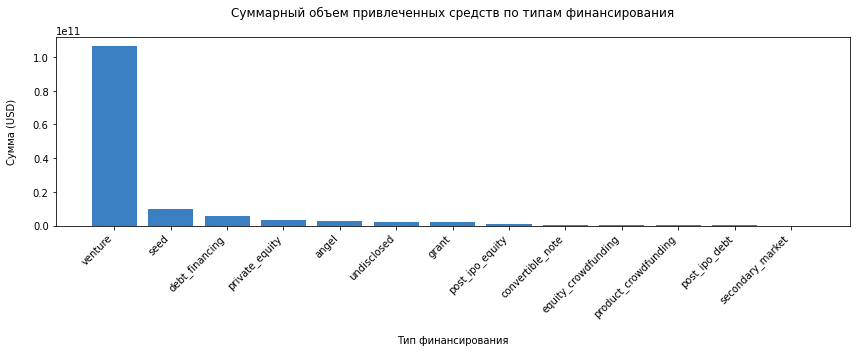

In [48]:
# Перечислим все типы финансирования из датасета
funding_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
                'convertible_note', 'debt_financing', 'angel', 'grant',
                'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                'secondary_market', 'product_crowdfunding']

# Посчитаем суммарный объем привлеченных средств по каждому типу
funding_total = df[funding_cols].sum().sort_values(ascending=False)

# Построим график суммарного объема по типам финансирования
plt.figure(figsize=(12, 5))
plt.bar(funding_total.index, funding_total.values, color='#3A7FC1')
plt.title('Суммарный объем привлеченных средств по типам финансирования\n')
plt.xlabel('\nТип финансирования')
plt.ylabel('Сумма (USD)\n')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

- `Venture`- финансирование абсолютно доминирует по суммарному объему привлеченных средств и составляет более 1×10¹¹ USD, что на порядок превышает все остальные типы;

- На втором месте `seed`- финансирование с 1×10¹⁰ USD, далее `debt_financing` и `private_equity` с заметно меньшими объемами;
- Типы `post_ipo_debt`, `secondary_market`, `product_crowdfunding` и `equity_crowdfunding` привлекли минимальные суммы и визуально стремятся к нулю на фоне `venture`.

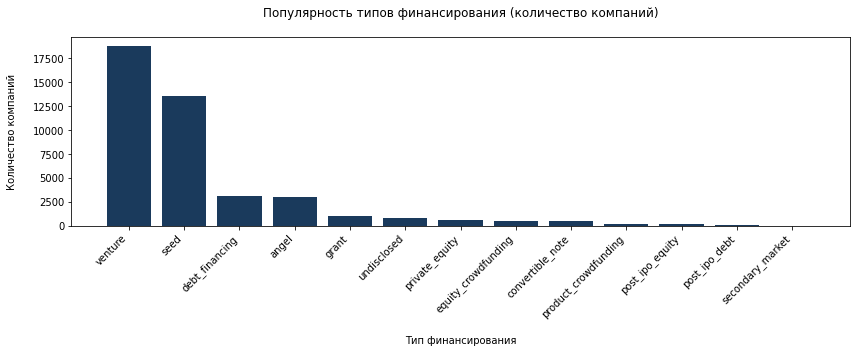

In [49]:
# Посчитаем количество компаний с ненулевым значением по каждому типу финансирования
funding_count = (df[funding_cols] > 0).sum().sort_values(ascending=False)

# Построим график популярности типов финансирования
plt.figure(figsize=(12, 5))
plt.bar(funding_count.index, funding_count.values, color='#1A3A5C')
plt.title('Популярность типов финансирования (количество компаний)\n')
plt.xlabel('\nТип финансирования')
plt.ylabel('Количество компаний\n')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

- `Venture` и `seed` лидируют одновременно по объему и по популярности и являются основными инструментами рынка стартапового финансирования;

- `debt_financing` и `angel` популярны (3000 компаний каждый), но по суммарному объему значительно уступают `venture`, типичные суммы в этих типах небольшие;
- `private_equity` встречается редко (около 500 компаний), однако по суммарному объему занимает 4-е место, редкий, но крупный инструмент;
- `post_ipo_equity`, `post_ipo_debt` и s`econdary_market` минимальны как по популярности, так и по объему и являются нишевыми инструментами для узкого круга компаний;
- `grant` популярнее (около 900 компаний), чем `private_equity`, но суммарный объем грантов значительно ниже, имеют небольшие суммы при относительно частом использовании.

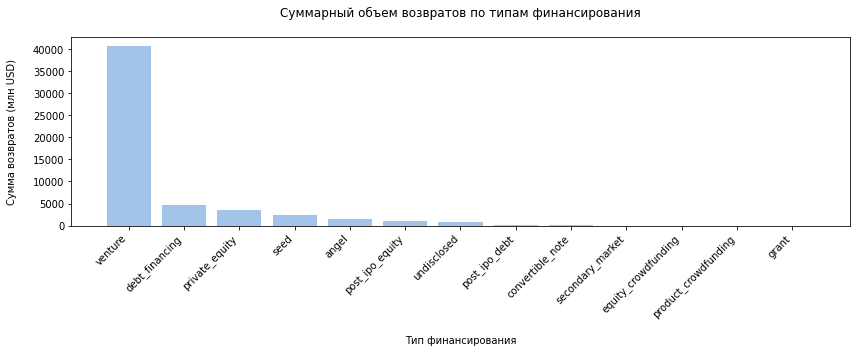

In [50]:
# Посчитаем суммарные возвраты по каждому типу финансирования за весь период
returns_total = returns_df.sum().sort_values(ascending=False)

# Построим график суммарных возвратов по типам финансирования
plt.figure(figsize=(12, 5))
plt.bar(returns_total.index, returns_total.values, color='#A1C4E8')
plt.title('Суммарный объем возвратов по типам финансирования\n')
plt.xlabel('\nТип финансирования')
plt.ylabel('Сумма возвратов (млн USD)\n')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

- `Venture` доминирует по возвратам (около 40 000 млн USD), что полностью согласуется с лидерством по объему привлеченных средств;

- `debt_financing` занимает 2-е место по возвратам (около 5 000 млн USD), хотя по объему привлеченных средств был на 3-м месте, является относительно эффективным инструментом возврата;
- `private_equity` на 3-м месте по возвратам, что соответствует его позиции по объему;
- `seed` несмотря на 2-е место по объему привлеченных средств и популярности занимает лишь 4-е место по возвратам, высокий риск потерь характерен для ранних стадий;
- `grant` и `product_crowdfunding` показывают минимальные возвраты, что логично, так как гранты не предполагают возврата средств по своей природе.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Посмотрим, как менялся рынок инвестиций год от года. Насколько активно происходили раунды финансирования и какие суммы компании получали в рамках одного раунда.

In [51]:
# Рассчитаем средний объем одного раунда для каждой компании
df['avg_round_size'] = df['funding_total_usd'].astype(float) / df['funding_rounds'].astype(float)

# Извлечем год финансирования из столбца mid_funding_at
df['funding_year'] = df['mid_funding_at'].dt.year

In [57]:

median_round_by_year = df.groupby('funding_year').agg(
    avg_round_size=('avg_round_size', 'median') 
).reset_index()

rounds_by_year = df.groupby('funding_year').agg(
    funding_rounds=('funding_rounds', 'sum')  
).reset_index()

median_round_by_year = median_round_by_year.sort_values('funding_year')
rounds_by_year = rounds_by_year.sort_values('funding_year')

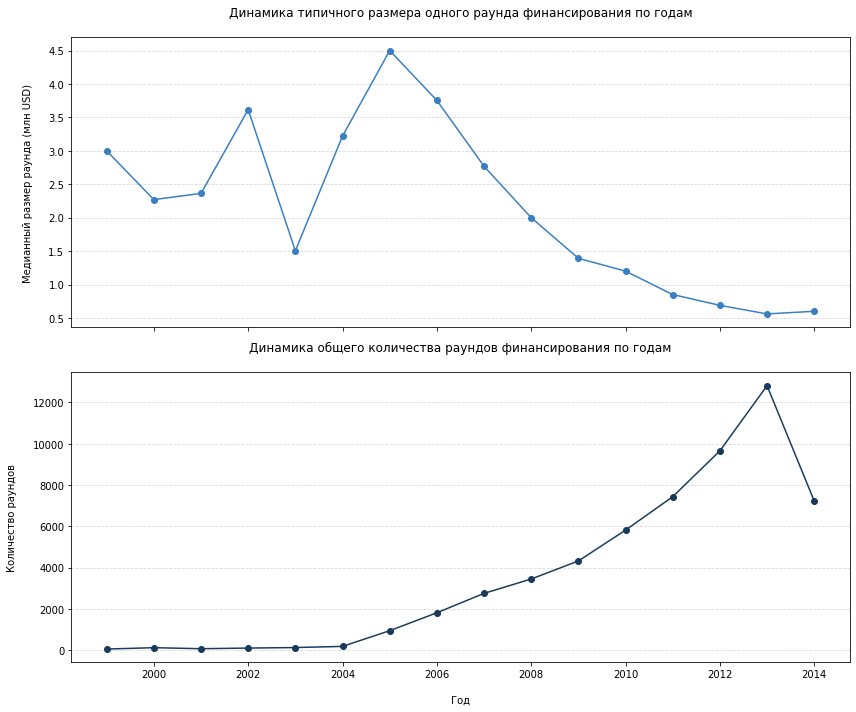

In [58]:
# Построим оба графика в единой системе координат
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# График 1. Медианный размер раунда
ax1.plot(
    median_round_by_year['funding_year'].astype(float).to_numpy(),
    (median_round_by_year['avg_round_size'] / 1e6).astype(float).to_numpy(),
    marker='o',
    color='#3A7FC1'
)
ax1.set_title('Динамика типичного размера одного раунда финансирования по годам\n')
ax1.set_ylabel('Медианный размер раунда (млн USD)\n')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# График 2. Количество раундов
ax2.plot(
    rounds_by_year['funding_year'].astype(float).to_numpy(),
    rounds_by_year['funding_rounds'].astype(float).to_numpy(),
    marker='o',
    color='#1A3A5C'
)
ax2.set_title('Динамика общего количества раундов финансирования по годам\n')
ax2.set_xlabel('\nГод')
ax2.set_ylabel('Количество раундов\n')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Два графика показывают противоположные тенденции:

- Количество раундов финансирования росло с 2005 по 2013 год с 1 000 до 12 800 раундов в год, то есть рынок стал активнее в 13 раз;

- При этом медианный размер одного раунда снижался с пика в 4.5 млн USD в 2005 году до 0.6 млн USD в 2014 году, то есть упал в 7 раз. Это говорит о том, что рынок становился массовым, инвестиции распределялись среди все большего числа компаний, но средняя сумма на одну сделку сокращалась;

- Снижение медианного размера раунда в 2003 году до 1.5 млн USD, скорее всего, связано с последствиями [dot-com](https://ru.wikipedia.org/wiki/Пузырь_доткомов) кризиса 2000-2001 годов. В 2014 году количество раундов снизилось до 7 300, что объясняется неполнотой данных за этот год.

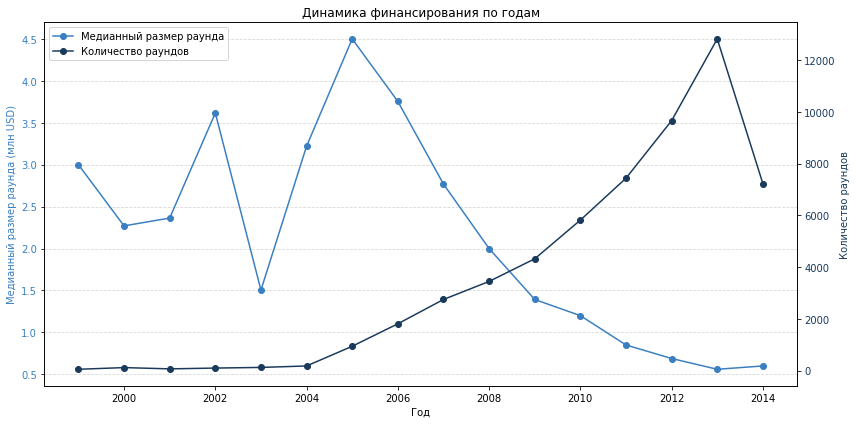

In [60]:
# Код ревьюера
fig, ax1 = plt.subplots(figsize=(12, 6))

# первая ось по медиане
color1 = '#3A7FC1'
ax1.plot(
    median_round_by_year['funding_year'].astype(float).to_numpy(),
    (median_round_by_year['avg_round_size'] / 1e6).astype(float).to_numpy(),
    marker='o',
    color=color1,
    label='Медианный размер раунда'
)
ax1.set_xlabel('Год')
ax1.set_ylabel('Медианный размер раунда (млн USD)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# вторая ось по количеству
ax2 = ax1.twinx()
color2 = '#1A3A5C'
ax2.plot(
    rounds_by_year['funding_year'].astype(float).to_numpy(),
    rounds_by_year['funding_rounds'].astype(float).to_numpy(),
    marker='o',
    color=color2,
    label='Количество раундов'
)
ax2.set_ylabel('Количество раундов', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)


plt.title('Динамика финансирования по годам')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Выясним, какие массовые сегменты рынка показали рост финансирования в 2014 году, и проследим их динамику по годам. Это поможет выявить наиболее перспективные направления для инвестиций.

Растущие в 2014 году сегменты: ['apps', 'internet', 'medical', 'nonprofits', 'real estate', 'saas', 'sports', 'technology', 'video']


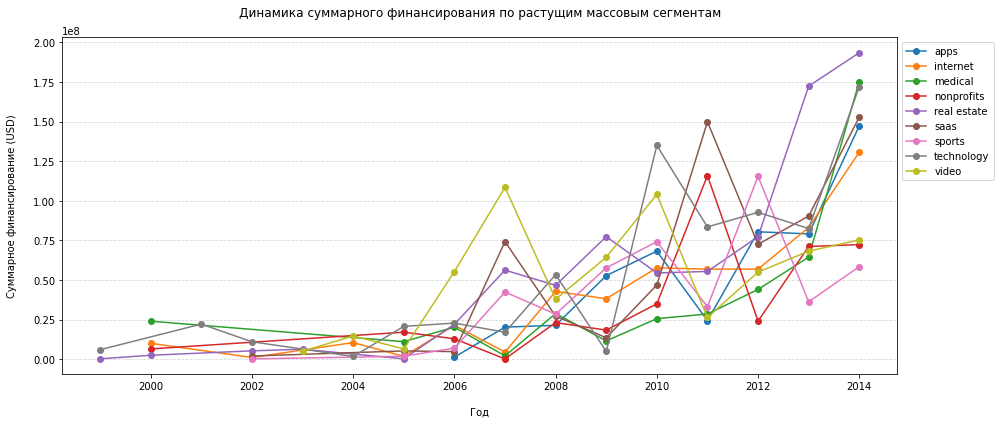

In [61]:
# Оставим только массовые сегменты и приведем финансирование к float
df_mass = df[~df['market'].isin(['niche', 'mid'])].copy()
df_mass['funding_total_usd'] = df_mass['funding_total_usd'].astype(float)

# Построим сводную таблицу с суммарным финансированием по годам и сегментам
pivot = df_mass.groupby(['funding_year', 'market'])['funding_total_usd'].sum().unstack('market')

# Отберем сегменты, которые показали рост в 2014 году по сравнению с 2013
growing_segments = pivot.columns[pivot.loc[2014] > pivot.loc[2013]]

# Уберем технические заглушки и оставим только растущие сегменты
exclude = ['unknown', 'startups']
pivot_growing = pivot[growing_segments].astype(float).drop(columns=exclude, errors='ignore')
print(f"Растущие в 2014 году сегменты: {list(pivot_growing.columns)}")

# Построим график динамики для каждого растущего сегмента
plt.figure(figsize=(14, 6))
for segment in pivot_growing.columns:
    data = pivot_growing[segment].dropna()
    plt.plot(data.index.astype(int), data.values, marker='o', label=segment)

plt.title('Динамика суммарного финансирования по растущим массовым сегментам\n')
plt.xlabel('\nГод')
plt.ylabel('Суммарное финансирование (USD)\n')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- Наиболее быстрый и уверенный рост в 2013-2014 годах показали `real estate` (195 млн USD в 2014), `medical` (175 млн USD) и `internet` (130 млн USD);

- Сегмент `saas` демонстрировал нестабильную динамику с резкими скачками. Пик был в 2011 году (150 млн USD), затем спад и снова рост;
- `technology` рос стабильно с 2009 по 2013 год, но в 2014 показал снижение, возможно из-за неполноты данных за этот год;
- Сегменты `apps` и `internet` начали активно расти только с 2009-2010 года, что совпадает с волной мобильных и интернет-стартапов;
- `video` и `sports` показывают нестабильную динамику с резкими пиками и провалами (ненадежные сегменты для инвестиций);
- Наиболее перспективными для инвестиций выглядят `real estate`, `medical` и `internet`, которые показывают стабильный рост без резких провалов.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

- Рассчитаем, какая доля вложенных средств возвращается инвесторам по каждому типу финансирования, и посмотрим, как этот показатель менялся год от года.

In [62]:
# Перечислим все типы финансирования из датасета
funding_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
                'convertible_note', 'debt_financing', 'angel', 'grant',
                'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                'secondary_market', 'product_crowdfunding']

# Извлечем год и посчитаем суммарное финансирование по каждому типу за каждый год
df['funding_year'] = df['mid_funding_at'].dt.year
funding_by_year = df.groupby('funding_year')[funding_cols].sum().astype(float)

# Возьмем возвраты из дополнительного датасета и приведем к float
returns_by_year = returns_df.astype(float)

# Разделим возвраты на финансирование и получим долю возврата по каждому типу и году
normalized = returns_by_year / (funding_by_year + 1e-60)

# Заменим значения больше 10 на пропуски, так как они аномальные
normalized = normalized.where(normalized <= 10)

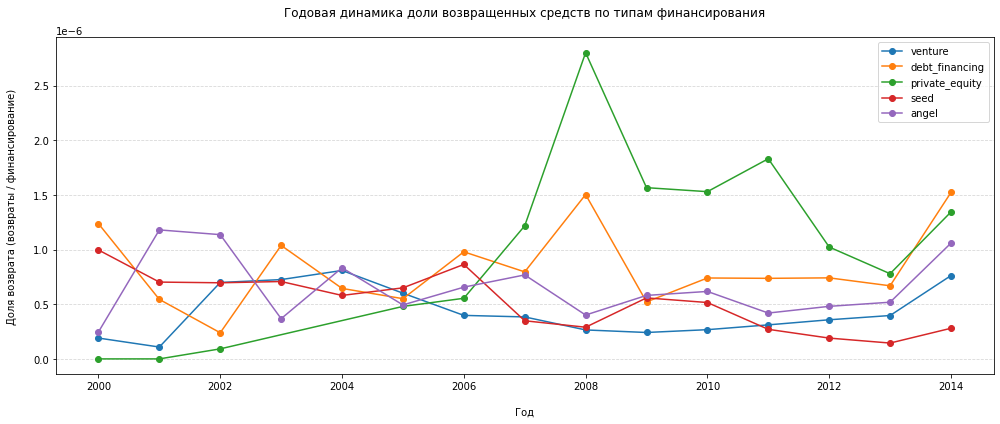

In [63]:
# Выберем типы финансирования для анализа
selected = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Построим график динамики доли возврата для каждого типа
plt.figure(figsize=(14, 6))
for col in selected:
    data = normalized[col].dropna()
    plt.plot(data.index.astype(int), data.values, marker='o', label=col)

plt.title('Годовая динамика доли возвращенных средств по типам финансирования\n')
plt.xlabel('\nГод')
plt.ylabel('Доля возврата (возвраты / финансирование)\n')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

- `private_equity` показывает наиболее волатильную динамику. Резкий пик в 2008 году (2.75×10⁻⁶), затем спад и снова рост к 2014 году (1.3×10⁻⁶);

- `debt_financing` демонстрирует наиболее устойчивый рост с 2009 года. Доля возврата стабильно держится на уровне 0.7-1.5×10⁻⁶ и продолжает расти к 2014 году;
- `venture` показывает низкую и стабильную долю возврата на протяжении всего периода (0.2-0.7×10⁻⁶) без выраженного роста;
- `seed` имеет наихудший показатель среди всех типов. Доля возврата снижается с 2006 года и к 2014 опускается до 0.3×10⁻⁶;
- `angel` демонстрирует умеренный рост с 2012 года после длительного периода стагнации;
- Наиболее устойчивый рост показателя возврата наблюдается у `debt_financing` и `private_equity`. Эти типы финансирования выглядят наиболее привлекательными с точки зрения возвратности средств.

## Шаг 5. Итоговый вывод и рекомендации


### Что было сделано

- Мы проанализировали исторические данные о финансировании стартапов за период с 1999 по 2014 год. Исходный датасет содержал 54 294 компании. После очистки от дубликатов, записей без данных о финансировании и выбросов в работе осталось 35 492 компании. Данные за 2014 год неполные, в них зафиксировано 7 757 раундов против 14 276 в 2013 году, поэтому выводы по 2014 году носят предварительный характер.
- В ходе анализа мы изучили четыре вещи, как устроен рынок по срокам и объемам финансирования, какие сегменты рынка растут, какие типы финансирования дают лучший возврат и как менялась активность инвестиций по годам.

---

### Что показал анализ

**1. Деньги идут в долгосрочные проекты.** Компании, которые привлекали финансирование дольше года, составляют всего 30% от общего числа, но забирают 61.9% всех вложенных денег. Компании с одним раундом  (их 59%)  получают лишь 30.6% средств. Это значит, что крупный капитал концентрируется в проектах с длинным горизонтом развития, а не в разовых сделках.

**2. Рынок стал массовым, но дешевым.** В 2005 году типичный размер одного раунда составлял около 4.5 млн USD. К 2014 году он упал до 0.6 млн USD, то есть в 7 раз. При этом количество раундов росло с 2005 по 2013 год и достигло пика в 12 800 раундов в год. Рынок стал активнее, но суммы в расчете на одну сделку сильно сократились.

**3. Три сегмента растут устойчиво.** Из всех массовых сегментов рынка только `medical`, `real estate` и `internet` показали рост финансирования в 2014 году по сравнению с 2013. `Medical` достиг 175 млн USD, `real estate` 195 млн USD, `internet` 130 млн USD. При этом `real estate` начал расти только с 2013 года, а `medical` рос стабильно с 2010 года без резких провалов.

**4. Venture приносит деньги, но возвращает мало.** Venture-финансирование доминирует по всем параметрам, более 18 000 компаний, свыше 1x10^11 USD привлеченных средств, 40 000 млн USD суммарных возвратов. Однако доля возврата относительно вложений остается низкой на протяжении всего периода. Это означает, что фонд зарабатывает на масштабе, а не на эффективности каждой сделки.

**5. Debt_financing эффективнее venture в расчете на вложенный рубль.** При объеме привлеченных средств на 3-м месте `debt_financing` занимает 2-е место по возвратам (около 5 000 млн USD) и показывает устойчивый рост доли возврата с 2009 года. Это значит, что долговое финансирование на зрелых стадиях отдает деньги обратно надежнее, чем венчур.

**6. Seed является популярным, но рискованным инструментом.** Примерно 13 000 компаний использовали seed-финансирование, это 2-е место по популярности. Но доля возврата снижается с 2006 года и к 2014 году опускается до минимума среди всех типов. Популярность seed не означает надежность, большинство компаний на ранней стадии не возвращают вложенное.

---

### Рекомендации заказчику

1. **Входить в сегмент medical.** Рекомендуем рассматривать медицинские стартапы как основное направление, потому что сегмент показал непрерывный рост финансирования с 2010 по 2014 год и достиг 175 млн USD. `Real estate` вырос быстрее (195 млн USD), но тренд там подтвержден только одним годом. `Medical` рос 4 года подряд без провалов, что говорит об устойчивом спросе инвесторов на этот сегмент, а не о случайном всплеске.

2. **Использовать venture как основной инструмент, подключать debt_financing на зрелых стадиях.** `Venture` - стандарт рынка, именно через него прошли более 18 000 компаний и привлечено свыше 1x10^11 USD. Отказываться от него нет смысла. Но когда компания уже доказала модель и нужно масштабирование, `debt_financing` дает лучшую отдачу. При вложениях на 3-м месте он обеспечивает возврат на 2-м месте (5 000 млн USD) и стабильно растет с 2009 года.

3. **Не входить в компании с одним раундом финансирования.** 59% компаний на рынке получили только один раунд, но на них приходится лишь 30.6% всех вложений. Крупный капитал идет в проекты с многораундовым финансированием, они составляют 30% компаний, но концентрируют 61.9% денег. Это значит, что рынок уже давно проголосовал деньгами за долгосрочные проекты.

4. **Не использовать seed как основной инструмент.** Несмотря на популярность (около 13 000 компаний), доля возврата по `seed` снижается с 2006 года и к 2014 году становится минимальной среди всех типов финансирования. Для фонда, который хочет предсказуемый возврат, `seed` на ранних стадиях несет высокий риск потери вложений без компенсации.

---

### Согласованность выводов

Выводы в основном согласуются между собой. Рост сегментов `medical`, `real estate` и `internet` подтверждается общим ростом активности рынка с 2005 по 2013 год. Доминирование `venture` по объему и популярности согласуется с его лидерством по абсолютным возвратам.

**Есть одно противоречие.** `seed` занимает 2-е место по популярности и объему привлеченных средств, но показывает худшую динамику доли возврата среди всех типов. Доля снижается с 2006 года и к 2014 году опускается до 0.3x10^-6. Это говорит о том, что популярность инструмента не означает его эффективности, большинство компаний на ранней стадии не возвращают вложенное, и рост числа seed-сделок только размывает общую доходность.

